# 2-1회차 실습 | 펭귄 데이터로 진짜 실력 확인하기

1-2때 342마리로 94.44%, 트리는 100%까지 나왔음.
근데 그거 "이미 본 데이터" 점수임. 새 펭귄한테도 그럴지는 모름.

오늘 그거 확인함: Train/Test Split -> 교차검증 -> GridSearchCV -> 최종 평가.


---
## 실습 규칙

1. `[예측]` 있으면 실행 전에 먼저 적을 것
2. 숫자 나오면 "왜 이렇게 나왔나" 한 줄 적을 것


In [1]:
# 1-2회차에서 썼던 것과 똑같은 준비 과정입니다.
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings

# LogisticRegression이 반복 횟수 경고를 자주 띄우는데,
# 오늘은 스케일링을 배우기 전이라 어쩔 수 없이 나오는 경고입니다. 결과에는 영향 없습니다.
warnings.filterwarnings("ignore", category=UserWarning)

candidates = ["AppleGothic", "Malgun Gothic", "NanumGothic", "NanumBarunGothic"]
installed = {f.name for f in fm.fontManager.ttflist}
chosen = next((c for c in candidates if c in installed), None)
if chosen:
    plt.rcParams["font.family"] = chosen
plt.rcParams["axes.unicode_minus"] = False

# 데이터 로드 + 1-2회차와 동일하게 측정값 결측만 제거 (342마리)
peng_raw = sns.load_dataset("penguins")
meas = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
peng = peng_raw.dropna(subset=meas).reset_index(drop=True)

X = peng[meas].values
y = peng["species"].values

print(f"펭귄 {len(peng)}마리, 특성 {X.shape[1]}개")
print(f"품종: {sorted(set(y))}")


펭귄 342마리, 특성 4개
품종: ['Adelie', 'Chinstrap', 'Gentoo']


---
## Part 1. 훈련=평가 착시 다시 보기

### Q1. 전체 데이터로 학습하고 같은 데이터로 채점하면?

**[예측]** 몇 % 나올 것 같음? ______%


In [2]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# 전체 342마리로 학습
dt_cheat = DecisionTreeClassifier(random_state=42)
dt_cheat.fit(X, y)

# 학습에 쓴 바로 그 342마리로 다시 예측하고 채점
pred_cheat = dt_cheat.predict(X)
cheat_acc = accuracy_score(y, pred_cheat)

print(f"전체로 학습 + 전체로 채점: {cheat_acc:.4f}")


전체로 학습 + 전체로 채점: 1.0000


### Q2. 그럼 어떻게 진짜 실력을 재나요?

방법은 하나입니다. **모델이 한 번도 못 본 데이터**로 시험을 봐야 합니다.

그러려면 처음부터 데이터를 두 덩어리로 나눠야 합니다.

| 덩어리 | 역할 | 비유 |
|--------|------|------|
| Train (훈련) | 모델이 패턴을 배우는 데이터 | 교과서 |
| Test (시험) | 학습 때 한 번도 안 보여준, 마지막 채점용 데이터 | 봉인된 시험지 |

**중요한 규칙: Test 데이터는 학습 중에 절대 들여다보면 안 됩니다.**
성능이 궁금하다고 미리 열어 보는 순간, 그 순간부터 이 시험지는 무효입니다.
(이런 행위를 **데이터 누수, Data Leakage**라고 부릅니다 — 1-2회차 Q13의 island 문제와 본질이 비슷합니다.)


---
## Part 2. Train / Test Split

### Q3. 데이터를 8:2로 나누기

`test_size=0.2`, `stratify=y`, `random_state=7` 씀.

**[예측]** Train/Test 각각 몇 마리? ______ / ______


In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20%를 시험용으로
    stratify=y,         # 종 비율을 원본과 동일하게 유지
    random_state= 7     # 결과 고정 (재현성)
)

print(f"Train: {X_train.shape[0]}마리")
print(f"Test : {X_test.shape[0]}마리")

# stratify가 실제로 비율을 지켰는지 확인
import pandas as pd
print("\n원본 비율      :", pd.Series(y).value_counts(normalize=True).round(3).to_dict())
print("Train 비율      :", pd.Series(y_train).value_counts(normalize=True).round(3).to_dict())
print("Test 비율       :", pd.Series(y_test).value_counts(normalize=True).round(3).to_dict())


Train: 273마리
Test : 69마리

원본 비율      : {'Adelie': 0.442, 'Gentoo': 0.36, 'Chinstrap': 0.199}
Train 비율      : {'Adelie': 0.443, 'Gentoo': 0.359, 'Chinstrap': 0.198}
Test 비율       : {'Adelie': 0.435, 'Gentoo': 0.362, 'Chinstrap': 0.203}


### Q4. 진짜 시험 점수 확인

**[예측]** Q1의 100%보다 낮을까? 몇 %일 것 같음? ______%


In [27]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)              # 학습은 Train으로만

y_pred = dt.predict(X_test)           # 예측은 Test로
acc_split = accuracy_score(y_test, y_pred)

print(f"[Q1] 전체로 학습+평가 (cheat) : {cheat_acc:.4f}")
print(f"[Q4] Train/Test 분리 후 평가  : {acc_split:.4f}")
print(f"격차                          : {(cheat_acc-acc_split)*100:.2f}%p")


[Q1] 전체로 학습+평가 (cheat) : 1.0000
[Q4] Train/Test 분리 후 평가  : 0.9130
격차                          : 8.70%p


### Q5. 근데 91.30%, 믿어도 됨?

**[예측]** random_state 다른 숫자로 바꾸면 정확도 똑같이 나올까, 달라질까?


In [5]:
# 5개의 서로 다른 random_state로 나눠서 비교합니다.
random_states_to_try = [51, 92, 14, 71, 60]

print(f"{'random_state':>12s}  {'test 정확도':>10s}")
print("-" * 26)
for rs in random_states_to_try:
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, stratify=y, random_state=rs)
    m = DecisionTreeClassifier(random_state=42)
    m.fit(Xtr, ytr)
    a = accuracy_score(yte, m.predict(Xte))
    print(f"{rs:>12d}  {a:>10.4f}")


random_state    test 정확도
--------------------------
          51      0.9420
          92      0.9420
          14      0.9565
          71      0.9710
          60      0.9275


---
## Part 3. 모델 갈아 끼우기

### 오늘 처음 나오는 모델 둘 (한 줄 설명만)

| 모델 | 한 줄 설명 |
|------|-----------|
| `DecisionTreeClassifier` | 질문 계속 던져서 조건별로 갈라나가는 모델 |
| `LogisticRegression` | 클래스별 확률 계산해서 제일 높은 걸 고르는 모델 |
| `KNeighborsClassifier` (KNN) | 가까운 이웃 k개 다수결로 정하는 모델 |

원리는 몰라도 됨. 오늘은 "모델 바꿔도 fit→predict→score는 똑같다"만 체험.

### Q6. 모델 셋 비교하기 (DecisionTree / LogReg / KNN)

**[예측]** 셋 중 뭐가 제일 잘할 것 같음? 뭐가 제일 못할 것 같음? (감으로 찍어볼 것)


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

models = {
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "LogisticRegression": LogisticRegression(max_iter=3000, random_state=42),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
}

print(f"{'모델':<22s}  {'test 정확도':>10s}")
print("-" * 36)
for name, m in models.items():
    m.fit(X_train, y_train)
    a = accuracy_score(y_test, m.predict(X_test))
    print(f"{name:<22s}  {a:>10.4f}")


모델                        test 정확도
------------------------------------
DecisionTree                0.9130
LogisticRegression          0.9710
KNN (k=5)                   0.7246


---
## Part 4. 교차검증 (Cross-Validation)

### Q7. K-Fold 직접 구현하기

용어 정리: Train(교과서) / **Validation**(모의고사, K-Fold 안에서 반복 사용) / Test(수능, 딱 1회).

Train 안에서 5등분, 매번 1등분은 Validation/나머지는 Train으로 5번 반복.
**Test는 여전히 안 건드림.**

**[예측]** 5개 점수가 거의 같을 것 같음, 꽤 다를 것 같음?


Fold 1: 0.9455
Fold 2: 0.9818
Fold 3: 0.9636
Fold 4: 0.9259
Fold 5: 0.9815

평균 = 0.9597, 표준편차 = 0.0216


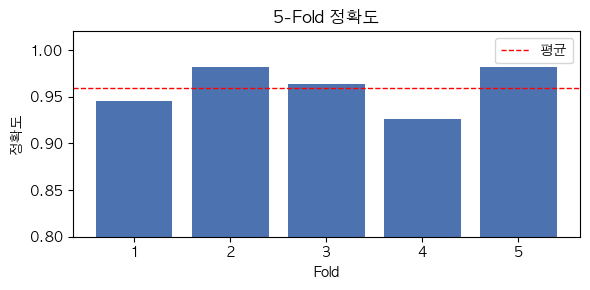

In [7]:
from sklearn.model_selection import StratifiedKFold

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_scores = []
for fold, (train_idx, val_idx) in enumerate(kf.split(X_train, y_train), 1):
    m = DecisionTreeClassifier(random_state=42)
    m.fit(X_train[train_idx], y_train[train_idx])
    score = accuracy_score(y_train[val_idx], m.predict(X_train[val_idx]))
    fold_scores.append(score)
    print(f"Fold {fold}: {score:.4f}")

print(f"\n평균 = {np.mean(fold_scores):.4f}, 표준편차 = {np.std(fold_scores):.4f}")

plt.figure(figsize=(6, 3))
plt.bar(range(1, 6), fold_scores, color="#4C72B0")
plt.axhline(np.mean(fold_scores), color="red", linestyle="--", linewidth=1, label="평균")
plt.ylim(0.8, 1.02)
plt.xlabel("Fold"); plt.ylabel("정확도")
plt.title("5-Fold 정확도")
plt.legend()
plt.tight_layout()
plt.show()


### Q8. for문 대신 한 줄로: cross_val_score

**[예측]** Q7 평균과 똑같이 나올까?


In [8]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    DecisionTreeClassifier(random_state=42),
    X_train, y_train,
    cv=5, scoring="accuracy"
)

print(f"각 Fold 정확도: {scores.round(4)}")
print(f"평균 ± 표준편차: {scores.mean():.4f} ± {scores.std():.4f}")


각 Fold 정확도: [0.9636 0.9273 0.9818 0.963  1.    ]
평균 ± 표준편차: 0.9671 ± 0.0241


### Q9. 세 모델, 교차검증으로 다시 비교

**[예측]** Q6이랑 순위 같을까, 바뀔까?


In [9]:
print(f"{'모델':<22s}  {'CV 평균':>8s}  {'CV 표준편차':>10s}")
print("-" * 46)
for name, m in models.items():
    s = cross_val_score(m, X_train, y_train, cv=5, scoring="accuracy")
    print(f"{name:<22s}  {s.mean():>8.4f}  {s.std():>10.4f}")


모델                         CV 평균     CV 표준편차
----------------------------------------------
DecisionTree              0.9671      0.0241
LogisticRegression        0.9855      0.0178
KNN (k=5)                 0.7801      0.0355


---
## Part 5. GridSearchCV

### Q10. max_depth 바꾸면 성능 바뀔까?

**[예측]** 1, 2, 3, 4, None 순서로 늘리면 정확도 계속 오를까, 어디서 꺾일까?


,max_depth,cv_mean,cv_std
0,1.0,0.780269,0.010436
1,2.0,0.930640,0.031079
2,3.0,0.937778,0.037627
3,4.0,0.970842,0.024634
4,NaN,0.967138,0.024143


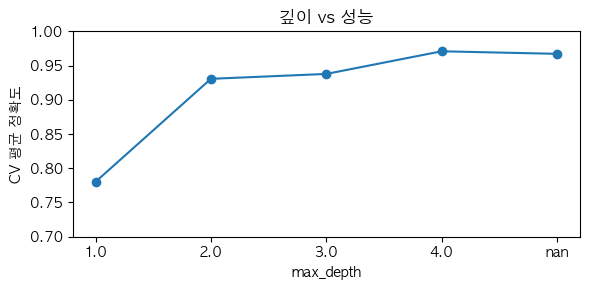

In [10]:
depth_candidates = [1, 2, 3, 4, None]
rows = []
for d in depth_candidates:
    s = cross_val_score(DecisionTreeClassifier(max_depth=d, random_state=42), X_train, y_train, cv=5)
    rows.append((d, s.mean(), s.std()))

df_depth = pd.DataFrame(rows, columns=["max_depth", "cv_mean", "cv_std"])
display(df_depth)

plt.figure(figsize=(6, 3))
plt.plot([str(d) for d in df_depth["max_depth"]], df_depth["cv_mean"], marker="o")
plt.ylim(0.7, 1.0)
plt.xlabel("max_depth"); plt.ylabel("CV 평균 정확도")
plt.title("깊이 vs 성능")
plt.tight_layout()
plt.show()


### Q11. GridSearchCV로 자동화하기

**중요:** GridSearchCV는 '설계자'가 아니라 '탐색기'임.
내가 넣은 후보 안에서만 비교함. 후보 범위 잘못 잡으면 아무리 돌려도 소용없음.

**[예측]** 최적 max_depth 몇일 것 같음? (Q10 보고 답해볼 것)


In [11]:
from sklearn.model_selection import GridSearchCV

param_grid = {"max_depth": [1, 2, 3, 4, None]}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy",
    return_train_score=True
)
grid.fit(X_train, y_train)

print(f"최적 파라미터: {grid.best_params_}")
print(f"최적 CV 정확도: {grid.best_score_:.4f}")

cv_df = pd.DataFrame(grid.cv_results_)[
    ["param_max_depth", "mean_train_score", "mean_test_score", "std_test_score", "rank_test_score"]
].rename(columns={
    "param_max_depth": "max_depth", "mean_train_score": "훈련 정확도",
    "mean_test_score": "검증 정확도", "std_test_score": "표준편차", "rank_test_score": "순위",
}).sort_values("순위")
display(cv_df)


최적 파라미터: {'max_depth': 4}
최적 CV 정확도: 0.9708


,max_depth,훈련 정확도,검증 정확도,표준편차,순위
3,4,0.997256,0.970842,0.024634,1
4,None,1.000000,0.967138,0.024143,2
2,3,0.983520,0.937778,0.037627,3
1,2,0.967040,0.930640,0.031079,4
0,1,0.790294,0.780269,0.010436,5


---
## Part 6. 최종 홀드아웃 평가

### Q12. 진짜 마지막 시험

**[예측]** CV 점수(0.9708)랑 최종 test 점수 비슷할까, 많이 다를까?


In [12]:
best_model = grid.best_estimator_          # GridSearchCV가 찾은 최적 모델
y_pred_final = best_model.predict(X_test)   # 한 번도 안 보여준 X_test로 예측
final_acc = accuracy_score(y_test, y_pred_final)

print(f"최적 파라미터        : {grid.best_params_}")
print(f"교차검증 점수         : {grid.best_score_:.4f}")
print(f"최종 홀드아웃 test 점수: {final_acc:.4f}")
print()
print(f"[참고] Q1 cheat 점수         : {cheat_acc:.4f}")
print(f"[참고] Q4 튜닝 전 split 점수 : {acc_split:.4f}")


최적 파라미터        : {'max_depth': 4}
교차검증 점수         : 0.9708
최종 홀드아웃 test 점수: 0.9130

[참고] Q1 cheat 점수         : 1.0000
[참고] Q4 튜닝 전 split 점수 : 0.9130


---
## 오늘 정리

빈칸 채워볼 것.

| 방법 | 정확도 |
|------|--------|
| 전체로 학습+평가 (cheat) | 1.0000 |
| Train/Test 분리 | ______ |
| 5-Fold 평균 (DecisionTree) | ______ |
| 5-Fold 평균 (LogisticRegression) | ______ |
| GridSearchCV 최적 CV 점수 | ______ |
| 최종 홀드아웃 test 점수 | ______ |

다음 시간: 전처리(스케일링/인코딩), Pipeline, Confusion Matrix/Precision/Recall/F1
